In [1]:
import os
from dask.distributed import Client
import sys

from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import numpy as np
import xarray as xr
import pandas as pd
import subprocess
from tqdm import tqdm
import pandas as pd
import intake
import datetime as dt
import metpy.calc as mpcalc
import dask.array as da
from metpy import units

import scipy

In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38591,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41169,Total threads: 2
Dashboard: /proxy/38763/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:33355,


In [3]:
def preprocess(ds):
    return ds.sel(level=850).sel(time=slice(t1,t2),latitude=slice(-5,-50),longitude=slice(105,170))

vnames = ["u","v","t"]
t1 = "2024-12-16 00:00"
t2 = "2024-12-16 23:00"
# lon_slice = slice(0,360)
# lat_slice = slice(-90,90)
chunks={}

t1_yy=pd.to_datetime(t1).strftime("%Y")
t1_yymm = pd.to_datetime(t1).strftime("%Y%m")

t=xr.open_mfdataset(f"/g/data/rt52/era5/pressure-levels/reanalysis/t/{t1_yy}/t_era5_oper_pl_{t1_yymm}*.nc",preprocess=preprocess)["t"].chunk({"latitude":-1,"longitude":-1})
#q=xr.open_mfdataset(f"/g/data/rt52/era5/pressure-levels/reanalysis/q/{t1_yy}/q_era5_oper_pl_{t1_yymm}*.nc",preprocess=preprocess)["q"].chunk({"latitude":-1,"longitude":-1})

t = t.rename({"latitude":"lat","longitude":"lon"})
#q = q.rename({"latitude":"lat","longitude":"lon"})

#dp = mpcalc.dewpoint_from_specific_humidity(700 * units.units.hectopascal, t, q)
theta = mpcalc.potential_temperature(850 * units.units.hectopascal, t).metpy.dequantify()  

interp_lon = np.arange(110,160.75,0.75)
interp_lat = np.arange(-45,-9.25,0.75)

theta = theta.interp(lat=interp_lat,lon=interp_lon,method="linear")
#theta = theta.rolling({"lat":3,"lon":3},center=True).mean().chunk({"lat":-1,"lon":-1})

In [4]:
def gaussian_filter_time_slice(time_slice,sigma):
    """
    Apply a gaussian filter to a time slice of data. For use with map_blocks
    """
    #out_ds = xr.DataArray(scipy.ndimage.gaussian_filter(time_slice.squeeze(), sigma, axes=axes),
    #                      dims=time_slice.squeeze().dims, coords=time_slice.squeeze().coords)
    out_ds = xr.DataArray(scipy.ndimage.gaussian_filter(
        time_slice.isel(time=0), sigma
        ),dims=time_slice.isel(time=0).dims, coords=time_slice.isel(time=0).coords)
    out_ds = out_ds.expand_dims("time")
    out_ds["time"] = time_slice.time
    return out_ds

# theta = theta.map_blocks(gaussian_filter_time_slice,
#                  kwargs={"sigma":2},
#                  template=theta)
#theta = theta.rolling({"lat":3,"lon":3},center=True).mean().chunk({"lat":-1,"lon":-1})

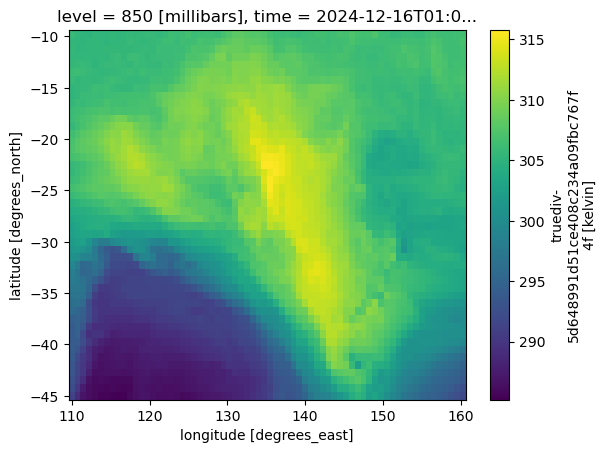

In [5]:
theta.isel(time=1).plot()

In [6]:
#Set up lat lon array and delta x/y array (lat lon distances in km)
x,y = np.meshgrid(theta.lon,theta.lat)
dx, dy = mpcalc.lat_lon_grid_deltas(x,y)

dx = xr.DataArray(np.array(dx),dims=["lat","lon"],coords={"lat":theta.lat.values, "lon":theta.lon.values[0:-1]}).\
        interp({"lon":theta.lon,"lat":theta.lat},method="linear",kwargs={"fill_value":"extrapolate"}).\
        chunk({"lat":theta.chunksizes["lat"][0], "lon":theta.chunksizes["lon"][0]})
dy = xr.DataArray(np.array(dy),dims=["lat","lon"],coords={"lat":theta.lat.values[0:-1], "lon":theta.lon.values}).\
        interp({"lon":theta.lon,"lat":theta.lat},method="linear",kwargs={"fill_value":"extrapolate"}).\
        chunk({"lat":theta.chunksizes["lat"][0], "lon":theta.chunksizes["lon"][0]})

dx = xr.where(dx==0,1,dx)

#Calculate the magnitude of the horizontal temperature gradient (in units of K / 100 km)
ddy_theta = (xr.DataArray(da.gradient(theta,axis=t.get_axis_num("lat")), dims=theta.dims, coords=theta.coords) / dy)
ddx_theta = (xr.DataArray(da.gradient(theta,axis=t.get_axis_num("lon")), dims=theta.dims, coords=theta.coords) / dx)

mag_theta = (np.sqrt( ddy_theta**2 + ddx_theta**2) * 1000 * 100)


# #Calculate the horizontal temperature advection
# t_adv = (-( (u * ddx_t) + (v * ddy_t) ))

# #Calculate vertical component of vorticity (in units s^-1)
# ddx_v = (xr.DataArray(da.gradient(v,axis=v.get_axis_num("lon")), dims=v.dims, coords=v.coords) / dx)
# ddy_u = (xr.DataArray(da.gradient(u,axis=u.get_axis_num("lat")), dims=u.dims, coords=u.coords) / dy)
# vorticity = (ddx_v - ddy_u)

# #Set up other aspects of front diagnostic. Coriolis and magnitude of equator to pole T gradient
# f = np.array(mpcalc.coriolis_parameter(y * units.units("degrees")))
# f = np.where(f==0,1e-10,f)
# mag_dt0 = 0.45

# #Calculate frontal diagnostic and save
# F = (mag_dt * vorticity) / (mag_dt0 * f)

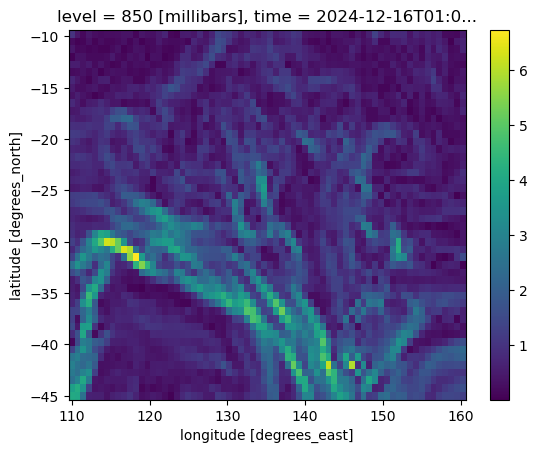

In [7]:
mag_theta.isel(time=1).plot()

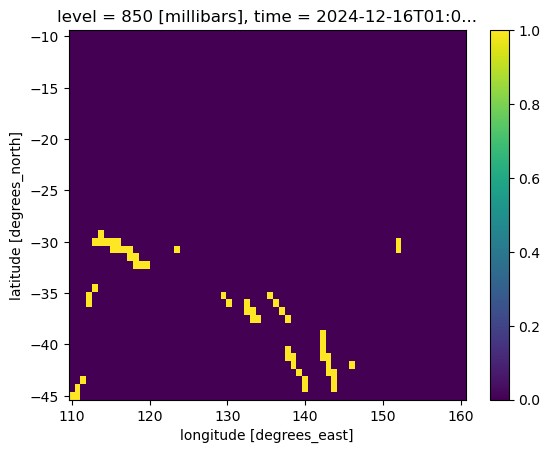

In [8]:
(mag_theta.isel(time=1)>4).plot()

In [9]:
#1 pixel = 25 X 25 km = 625 km**2
# 100,000 km**2 / 625 km**2 = 160

#1 pixel = 75 x 75 km = 5625 km**2
# 100,000 km**2 / 5625 km**2 = 17.7
# 50,000 km**2 / 5625 km**2 = 8.8

import matplotlib.pyplot as plt
import skimage

def filter_time_slice(time_slice):
    """
    Apply a gaussian filter to a time slice of data. For use with map_blocks
    """
    #out_ds = xr.DataArray(scipy.ndimage.gaussian_filter(time_slice.squeeze(), sigma, axes=axes),
    #                      dims=time_slice.squeeze().dims, coords=time_slice.squeeze().coords)
    out_ds = xr.DataArray(
        skimage.morphology.remove_small_objects(skimage.measure.label(time_slice.squeeze())>0,8,connectivity=2)
        ,dims=time_slice.isel(time=0).dims, coords=time_slice.isel(time=0).coords)
    out_ds = out_ds.expand_dims("time")
    out_ds["time"] = time_slice.time
    return out_ds


mask = mag_theta>4
mask = mask.map_blocks(filter_time_slice,
                 template=mask)


#plt.pcolormesh(x,y,skimage.morphology.remove_small_objects(skimage.measure.label(mask),160,connectivity=2))
#plt.pcolormesh(x,y,skimage.morphology.remove_small_objects(skimage.measure.label(mask)>0,8,connectivity=2))

In [10]:
mask#.plot(col="time")

<xarray.DataArray (time: 24, lat: 48, lon: 68)> Size: 78kB
dask.array<<this-array>-filter_time_slice, shape=(24, 48, 68), dtype=bool, chunksize=(1, 48, 68), chunktype=numpy.ndarray>
Coordinates:
    level    int32 4B dask.array<chunksize=(), meta=np.ndarray>
  * time     (time) datetime64[ns] 192B 2024-12-16 ... 2024-12-16T23:00:00
  * lat      (lat) float64 384B -45.0 -44.25 -43.5 -42.75 ... -11.25 -10.5 -9.75
  * lon      (lon) float64 544B 110.0 110.8 111.5 112.2 ... 158.8 159.5 160.2

In [12]:
sys.path.append('/g/data/ng72/ab4502/hot-cloudy/modules/')
from fronts import *

In [38]:
#domain_id = "AUS-11"
domain_id = "AUST-04"
freq = "1hr"
lat_slice = slice(-50,-5)
lon_slice = slice(100,170)
chunks = {"time":{},"lat":-1,"lon":-1}
smooth = False
sigma=None

p = 850

#front_thresh = 8*(units.units.K / units.units.km)

interp_lon = np.arange(110,160,0.75)
interp_lat = np.arange(-45,-9.25,0.75)    

ta = load_barra_variable("ta"+str(p),t1,t2,domain_id,freq,lat_slice,lon_slice,chunks=chunks,smooth=smooth,sigma=sigma)

theta = mpcalc.potential_temperature(850 * units.units.hectopascal, ta).metpy.dequantify()#.interp(lon=interp_lon,lat=interp_lat).chunk({"time":1})

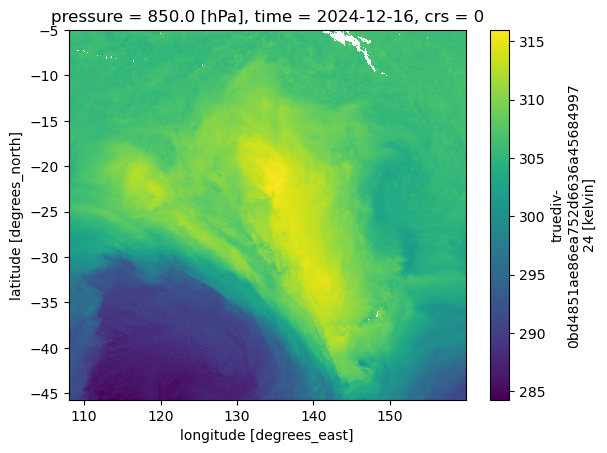

In [35]:
theta.isel(time=0).plot()

In [39]:
import xesmf
ds_out = xr.Dataset(
    {
        "lat": (["lat"], interp_lat, {"units": "degrees_north"}),
        "lon": (["lon"], interp_lon, {"units": "degrees_east"}),
    }
)
regridder = xesmf.Regridder(theta, ds_out, "conservative")
dr_out = regridder(theta, keep_attrs=True)

In [42]:
dr_out#.isel(time=0).plot()

<xarray.DataArray 'truediv-0bd4851ae86ea752d6636a4568499724' (time: 24,
                                                              lat: 48, lon: 67)> Size: 617kB
dask.array<sum-aggregate, shape=(24, 48, 67), dtype=float64, chunksize=(12, 48, 67), chunktype=numpy.ndarray>
Coordinates:
    pressure  float64 8B ...
  * time      (time) datetime64[ns] 192B 2024-12-16 ... 2024-12-16T23:00:00
    crs       int32 4B ...
  * lat       (lat) float64 384B -45.0 -44.25 -43.5 ... -11.25 -10.5 -9.75
  * lon       (lon) float64 536B 110.0 110.8 111.5 112.2 ... 158.0 158.8 159.5
Attributes:
    units:          kelvin
    regrid_method:  conservative

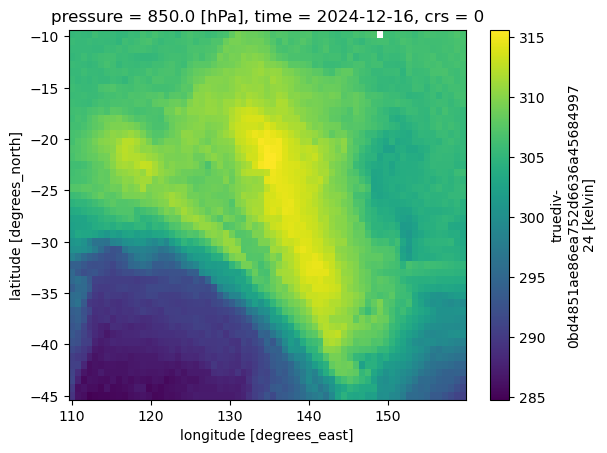

In [41]:
theta.isel(time=0).interp(lon=interp_lon,lat=interp_lat).plot()

In [54]:
#Set up lat lon array and delta x/y array (lat lon distances in km)
x,y = np.meshgrid(theta.lon,theta.lat)
dx, dy = mpcalc.lat_lon_grid_deltas(x,y)

dx = xr.DataArray(np.array(dx),dims=["lat","lon"],coords={"lat":theta.lat.values, "lon":theta.lon.values[0:-1]}).\
        interp({"lon":theta.lon,"lat":theta.lat},method="linear",kwargs={"fill_value":"extrapolate"}).\
        chunk({"lat":theta.chunksizes["lat"][0], "lon":theta.chunksizes["lon"][0]})
dy = xr.DataArray(np.array(dy),dims=["lat","lon"],coords={"lat":theta.lat.values[0:-1], "lon":theta.lon.values}).\
        interp({"lon":theta.lon,"lat":theta.lat},method="linear",kwargs={"fill_value":"extrapolate"}).\
        chunk({"lat":theta.chunksizes["lat"][0], "lon":theta.chunksizes["lon"][0]})

dx = xr.where(dx==0,1,dx)

#Calculate the magnitude of the horizontal temperature gradient (in units of K / 100 km)
ddy_theta = (xr.DataArray(da.gradient(theta,axis=t.get_axis_num("lat")), dims=theta.dims, coords=theta.coords) / dy)
ddx_theta = (xr.DataArray(da.gradient(theta,axis=t.get_axis_num("lon")), dims=theta.dims, coords=theta.coords) / dx)

mag_theta = (np.sqrt( ddy_theta**2 + ddx_theta**2) * 1000 * 100)

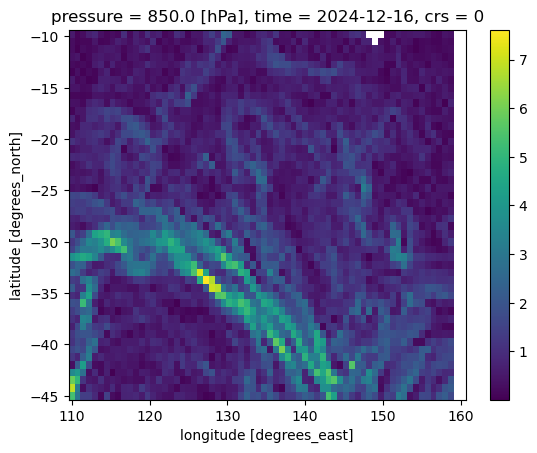

In [55]:
mag_theta.isel(time=0).plot()

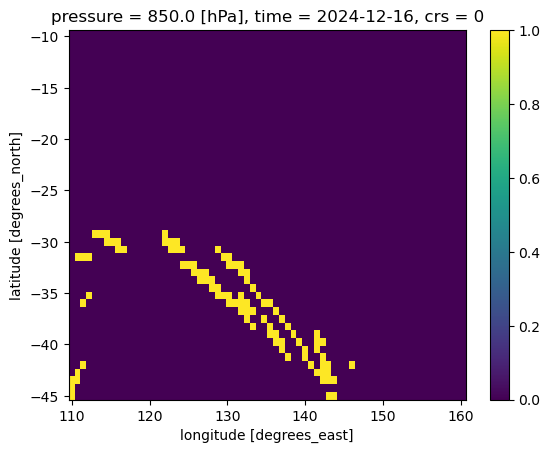

In [56]:
(mag_theta.isel(time=0)>4).plot()

In [57]:
mask = mag_theta>4
mask = mask.map_blocks(filter_time_slice,
                template=mask)
mask = xr.where(mag_theta.isnull(),np.nan,mask)

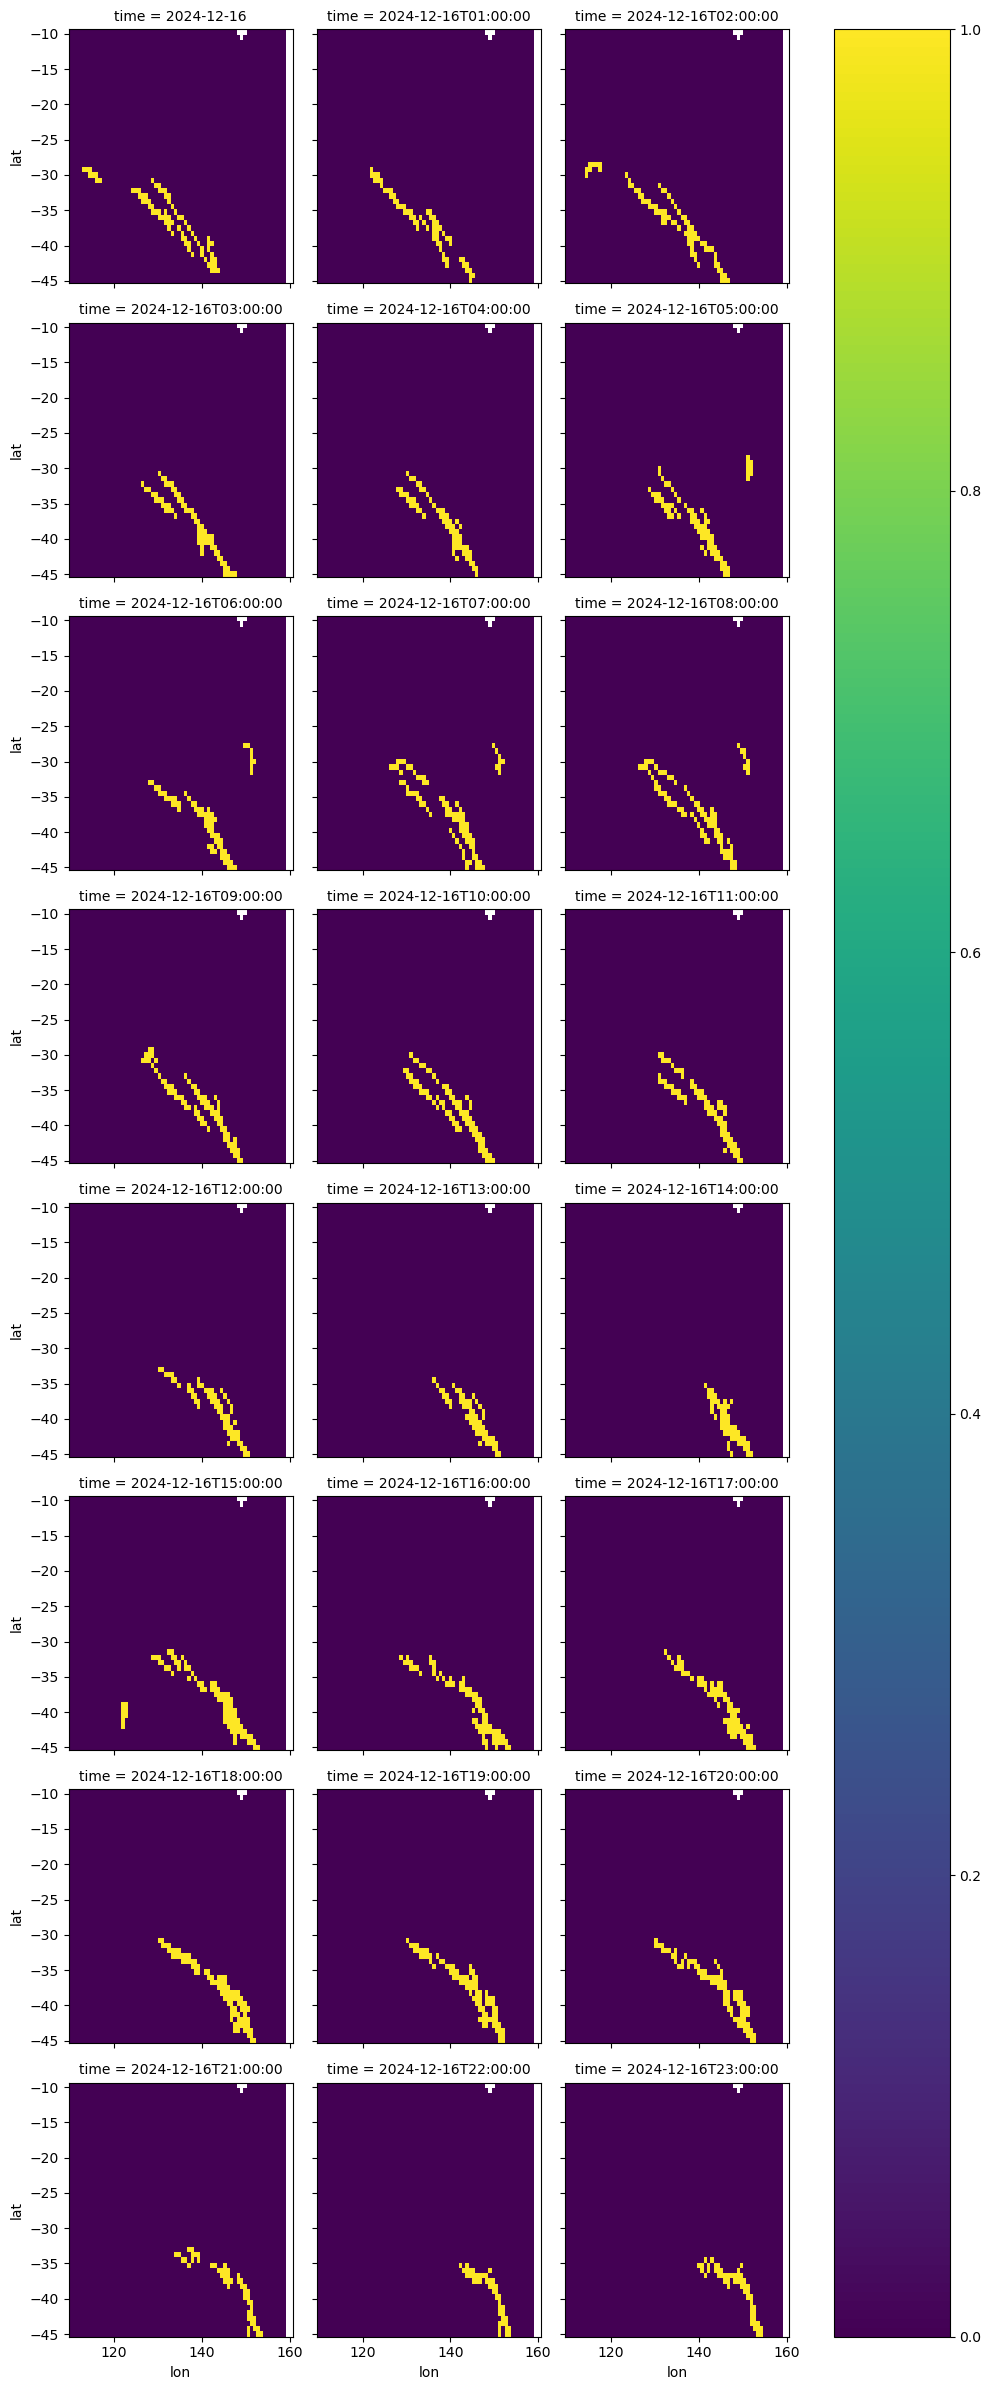

In [58]:
mask.plot(col="time",col_wrap=3)